# 01_Resourcesat2_LISS3_ML_Masterclass

**Offline workshop • Resourcesat-2 LISS-III • NumPy + pandas + Matplotlib**

> Teaching principle: first understand the ML idea, then implement a small version ourselves. No scikit-learn is required.


## 1. Mission context — why four bands are interesting

Resourcesat-2 LISS-III has four spectral bands: Green, Red, Near-Infrared (NIR) and Short-Wave Infrared (SWIR). NRSC documents LISS-III at about 24 m spatial resolution. For this workshop we will treat each pixel as a **data record**:

`[Green, Red, NIR, SWIR] → one observation`

That turns a satellite image into a machine-learning table.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg

In [12]:
plt.rcParams["figure.figsize"] = (8, 6)

DATA_DIR = Path(r"C:\Users\user\bhoonidhiData")

tif_files = list(DATA_DIR.glob("*.tif"))

print("TIFF files found:")
for f in tif_files:
    print(" ", f.name)

TIFF files found:
  BAND2.tif
  BAND3.tif
  BAND4.tif
  BAND5.tif


In [13]:
# 1. Read each of the 4 files directly
b1 = mpimg.imread(tif_files[0])
b2 = mpimg.imread(tif_files[1])
b3 = mpimg.imread(tif_files[2])
b4 = mpimg.imread(tif_files[3])

# 2. Convert integer values to floating point numbers for calculations
b1 = b1.astype(np.float32)
b2 = b2.astype(np.float32)
b3 = b3.astype(np.float32)
b4 = b4.astype(np.float32)

# 3. Store them in a list
bands = [b1, b2, b3, b4]

# 4. Print the shape (dimensions) of each band
print("Band 1 Shape:", b1.shape)
print("Band 2 Shape:", b2.shape)
print("Band 3 Shape:", b3.shape)
print("Band 4 Shape:", b4.shape)

Band 1 Shape: (7113, 7744)
Band 2 Shape: (7113, 7744)
Band 3 Shape: (7113, 7744)
Band 4 Shape: (7113, 7744)


## 2. Quick visual inspection

We first behave like data scientists, not ML programmers: inspect the data, shape, range and visual appearance.

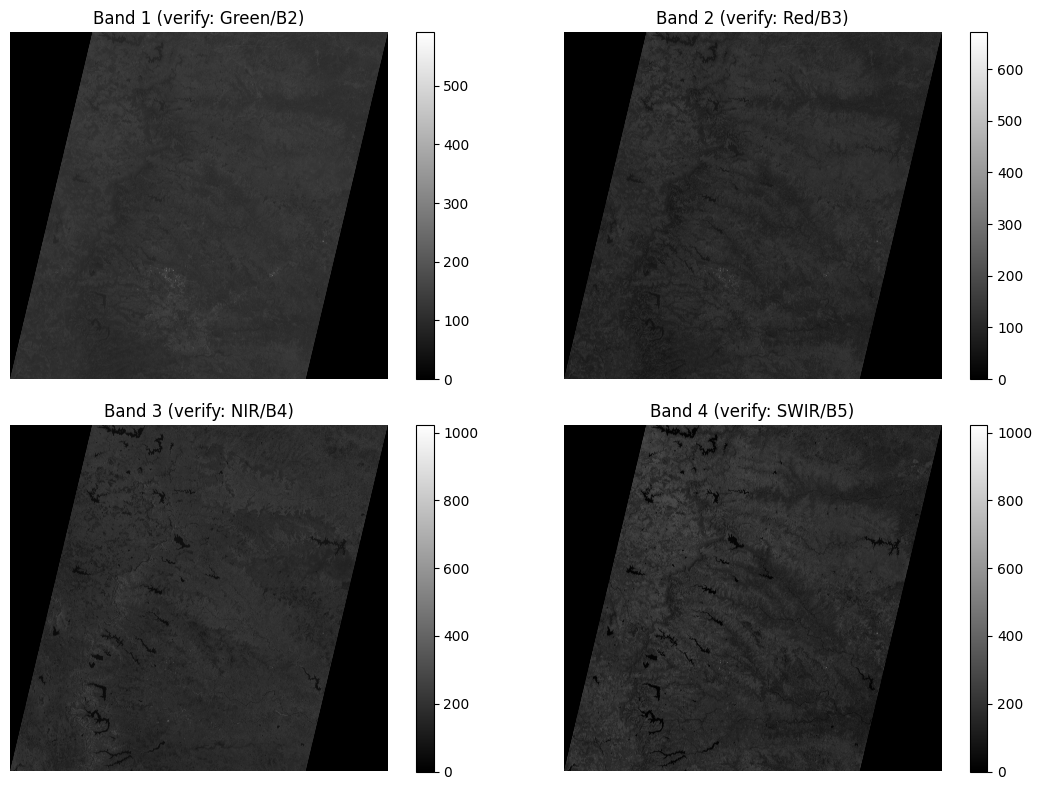

In [8]:

if len(tif_files) >= 4:
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    names = ["Band 1 (verify: Green/B2)", "Band 2 (verify: Red/B3)",
             "Band 3 (verify: NIR/B4)", "Band 4 (verify: SWIR/B5)"]
    for a, b, name in zip(ax.ravel(), bands, names):
        im = a.imshow(b, cmap="gray")
        a.set_title(name)
        a.axis("off")
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout()


In [14]:

if len(tif_files) >= 4:
    for i,b in enumerate(bands,1):
        print(f"Band {i}: shape={b.shape}, min={np.nanmin(b):.2f}, max={np.nanmax(b):.2f}, mean={np.nanmean(b):.2f}")


Band 1: shape=(7113, 7744), min=0.00, max=591.00, mean=92.77
Band 2: shape=(7113, 7744), min=0.00, max=671.00, mean=85.99
Band 3: shape=(7113, 7744), min=0.00, max=1023.00, mean=139.82
Band 4: shape=(7113, 7744), min=0.00, max=1023.00, mean=136.60


## 3. Turn pixels into a pandas table

A pixel becomes one row and the four bands become features.

We also calculate NDVI:

`NDVI = (NIR - Red) / (NIR + Red)`

This is useful as a teaching feature, but **do not confuse an index with a land-cover label**.

In [15]:

if len(tif_files) >= 4:
    G, R, NIR, SWIR = bands
    eps = 1e-6
    ndvi = (NIR - R) / (NIR + R + eps)
    rows, cols = np.indices(G.shape)
    sample = pd.DataFrame({
        "row": rows.ravel(),
        "col": cols.ravel(),
        "green": G.ravel(),
        "red": R.ravel(),
        "nir": NIR.ravel(),
        "swir": SWIR.ravel(),
        "ndvi": ndvi.ravel()
    })
    sample = sample.replace([np.inf, -np.inf], np.nan).dropna()
    print(sample.head())
    print("Number of valid pixels:", len(sample))


   row  col  green  red  nir  swir  ndvi
0    0    0    0.0  0.0  0.0   0.0   0.0
1    0    1    0.0  0.0  0.0   0.0   0.0
2    0    2    0.0  0.0  0.0   0.0   0.0
3    0    3    0.0  0.0  0.0   0.0   0.0
4    0    4    0.0  0.0  0.0   0.0   0.0
Number of valid pixels: 55083072


# Supervised learning: teach the machine with examples

### Classroom story

Imagine we tell the computer:

- these pixels are **vegetation**
- these pixels are **water**
- these pixels are **built-up/soil**

The model learns a relationship between spectral features and our labels.

For a low-end laptop, we will deliberately use a **small labelled sample** and implement a simple classifier ourselves. The goal is to understand the learning loop, not to build a production remote-sensing classifier.

## 4. Create labels with simple spectral rules

For a workshop, manually clicking hundreds of pixels is too slow and would require another library. Instead, we create **teaching labels** using transparent rules based on NDVI and brightness.

These are *proxy labels*, not ground truth. In a real project, labels should come from field observations, authoritative maps or carefully interpreted reference data.

This is a powerful discussion point:

> If our labels are wrong, can ML magically make them right?

In [ ]:

# Teaching labels. Thresholds are deliberately exposed so students can experiment.
if len(tif_files) >= 4:
    brightness = (G + R + NIR + SWIR) / 4.0

    # These are illustrative rules, not scientific land-cover classification.
    y = np.full(len(sample), -1, dtype=int)
    s_ndvi = sample["ndvi"].to_numpy()
    s_red = sample["red"].to_numpy()
    s_nir = sample["nir"].to_numpy()

    # 0 = water-like, 1 = vegetation-like, 2 = other
    water = (s_ndvi < 0.0) & (s_nir < np.nanpercentile(s_nir, 45))
    veg = (s_ndvi > 0.35)
    other = ~(water | veg)

    y[water] = 0
    y[veg] = 1
    y[other] = 2
    sample["label"] = y

    print(sample["label"].value_counts().sort_index())


## 5. Train a tiny nearest-centroid classifier

For each class we calculate its average feature vector — its **centroid**.

Prediction:

1. take a new pixel
2. calculate its distance from each class centroid
3. choose the nearest centroid

This is not the most sophisticated classifier. That is exactly why it is good for teaching: students can see the complete supervised-learning mechanism.

In [ ]:

def fit_nearest_centroid(X, y):
    classes = np.unique(y)
    centroids = {}
    for c in classes:
        centroids[c] = X[y == c].mean(axis=0)
    return centroids

def predict_nearest_centroid(X, centroids):
    classes = sorted(centroids.keys())
    C = np.vstack([centroids[c] for c in classes])
    # squared Euclidean distance: samples x classes
    d2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    return np.array([classes[i] for i in np.argmin(d2, axis=1)])

features = ["green","red","nir","swir"]
work = sample[sample["label"] >= 0].copy()

# Simple reproducible split
rng = np.random.default_rng(42)
idx = rng.permutation(len(work))
cut = int(0.7 * len(work))
train = work.iloc[idx[:cut]]
test  = work.iloc[idx[cut:]]

# Standardise using training statistics so one band does not dominate by scale.
mu = train[features].mean().to_numpy()
sigma = train[features].std().to_numpy() + 1e-8

X_train = (train[features].to_numpy() - mu) / sigma
X_test  = (test[features].to_numpy() - mu) / sigma

centroids = fit_nearest_centroid(X_train, train["label"].to_numpy())
pred = predict_nearest_centroid(X_test, centroids)

accuracy = np.mean(pred == test["label"].to_numpy())
print("Simple hold-out accuracy:", round(accuracy, 3))
print("Centroids:")
for c,v in centroids.items():
    print(c, np.round(v,2))


In [ ]:

# Confusion matrix with NumPy only
classes = sorted(centroids.keys())
cm = np.zeros((len(classes), len(classes)), dtype=int)
for actual, predicted in zip(test["label"], pred):
    cm[int(actual), int(predicted)] += 1

print("Rows = actual, columns = predicted")
print(pd.DataFrame(cm, index=classes, columns=classes))


## 6. The exciting part: classify the whole image

Now the model is no longer looking at individual examples. It predicts a class for every valid pixel.

That gives us a **thematic map**.

For classroom performance, use a downsampled image if the TIFF is large. The idea is more important than processing every pixel at full resolution.

In [ ]:

if len(tif_files) >= 4:
    # Downsample for speed on low-end laptops.
    step = max(1, int(max(G.shape) / 700))
    Gs, Rs, Ns, Ss = G[::step,::step], R[::step,::step], NIR[::step,::step], SWIR[::step,::step]
    flat = np.column_stack([Gs.ravel(), Rs.ravel(), Ns.ravel(), Ss.ravel()])
    valid = np.isfinite(flat).all(axis=1)
    Z = np.zeros(len(flat), dtype=int)
    Z[:] = -1
    Z[valid] = predict_nearest_centroid((flat[valid]-mu)/sigma, centroids)
    classified = Z.reshape(Gs.shape)

    plt.figure(figsize=(10,7))
    plt.imshow(classified, cmap="viridis", vmin=min(classes), vmax=max(classes))
    plt.title("Teaching classification map: 0=water-like, 1=vegetation-like, 2=other")
    plt.axis("off")
    plt.colorbar()
    plt.show()


# Unsupervised learning: discover groups without labels

Now remove the labels.

Question to students:

> “If I give you thousands of pixels but never tell you what they are, can the computer still find patterns?”

Yes. A classic answer is **K-means clustering**.

Algorithm:

1. choose K starting centres
2. assign each pixel to its nearest centre
3. move each centre to the mean of its assigned pixels
4. repeat until centres stop moving

The computer discovers spectral groups. **We interpret them afterward.** Cluster 0 does not inherently mean “water”.

In [ ]:

def kmeans_numpy(X, k=3, iterations=12, seed=7):
    rng = np.random.default_rng(seed)
    start = rng.choice(len(X), size=k, replace=False)
    centers = X[start].copy()

    for it in range(iterations):
        d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(axis=2)
        labels = np.argmin(d2, axis=1)

        new_centers = centers.copy()
        for j in range(k):
            if np.any(labels == j):
                new_centers[j] = X[labels == j].mean(axis=0)

        movement = np.sqrt(((new_centers-centers)**2).sum())
        centers = new_centers
        print(f"iteration {it+1:02d} | center movement = {movement:.4f}")

        if movement < 1e-4:
            break
    return labels, centers

# Use a small random sample to keep laptops responsive.
if len(tif_files) >= 4:
    X_all = sample[features].to_numpy()
    Xn = (X_all - X_all.mean(axis=0)) / (X_all.std(axis=0)+1e-8)
    take = min(12000, len(Xn))
    ix = np.random.default_rng(3).choice(len(Xn), take, replace=False)
    cluster_labels, cluster_centers = kmeans_numpy(Xn[ix], k=3)
    print("Cluster centres:\n", np.round(cluster_centers,2))


## Mini challenge — interpret the clusters

Give each group a nickname based on its spectral signature.

Ask students to inspect:

- mean NIR
- mean Red
- NDVI
- SWIR

Then ask:

**“Did K-means know the word vegetation?”**

No. It only knew numerical similarity.

# Reinforcement learning: make the satellite scene a playground

Reinforcement learning is different.

There is:

- an **agent**
- a **state**
- an **action**
- a **reward**
- a repeated interaction

We will make a tiny educational environment from the satellite image.

The agent is a virtual explorer. It can move up/down/left/right. Its reward is related to moving toward pixels with higher vegetation signal (NDVI).

**Important scientific caveat:** this is an educational RL analogy, not a standard operational remote-sensing workflow. The satellite image supplies the environment/reward signal; it does not make this automatically a useful land-cover decision system.

In [ ]:

# Build a small RL grid from NDVI.
# This uses only NumPy and Matplotlib.
if len(tif_files) >= 4:
    step = max(1, int(max(NIR.shape) / 80))
    small_ndvi = ((NIR - R) / (NIR + R + 1e-6))[::step, ::step]
    small_ndvi = np.nan_to_num(small_ndvi, nan=0.0, posinf=0.0, neginf=0.0)
    # Keep a manageable 40x40-ish world.
    h,w = small_ndvi.shape
    h2,w2 = min(h,40), min(w,40)
    nd = small_ndvi[:h2,:w2]

    # Reward: positive when entering a higher-NDVI cell.
    def reward(r,c,old_r,old_c):
        return float(nd[r,c] - nd[old_r,old_c])

    actions = [(-1,0),(1,0),(0,-1),(0,1)]
    Q = np.zeros((h2,w2,4), dtype=np.float32)

    alpha = 0.2
    gamma = 0.9
    epsilon = 0.25
    rng = np.random.default_rng(5)

    for episode in range(500):
        r,c = rng.integers(h2), rng.integers(w2)
        for t in range(80):
            if rng.random() < epsilon:
                a = rng.integers(4)
            else:
                a = np.argmax(Q[r,c])

            dr,dc = actions[a]
            nr = int(np.clip(r+dr,0,h2-1))
            nc = int(np.clip(c+dc,0,w2-1))
            rew = reward(nr,nc,r,c)

            Q[r,c,a] += alpha * (rew + gamma*np.max(Q[nr,nc]) - Q[r,c,a])
            r,c = nr,nc

    # Greedy trajectory
    r,c = h2//2, w2//2
    path = [(r,c)]
    for _ in range(100):
        a = np.argmax(Q[r,c])
        dr,dc = actions[a]
        r = int(np.clip(r+dr,0,h2-1))
        c = int(np.clip(c+dc,0,w2-1))
        path.append((r,c))

    rr,cc = zip(*path)
    plt.figure(figsize=(9,7))
    plt.imshow(nd, cmap="gray")
    plt.plot(cc, rr, marker="o", markersize=2)
    plt.title("Educational RL explorer: trajectory shaped by NDVI reward")
    plt.axis("off")
    plt.show()


## Final reflection

Ask students to complete this sentence:

- **Supervised:** “I learn from ______.”
- **Unsupervised:** “I discover ______.”
- **Reinforcement:** “I learn by ______.”

Expected concepts:

- labelled examples
- structure/patterns in unlabelled data
- trial, feedback and reward

### Exit challenge

If tomorrow you receive a new satellite scene and want a crop/non-crop map:

1. What would you need for supervised learning?
2. What could K-means give you without labels?
3. Why is RL probably not your first choice for this task?

There is no need to memorize algorithms. The goal is to recognize the **learning setup**.